# Linear SVM

In [1]:
from pathlib import Path
import joblib
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

BASE_DIR = Path.cwd().parents[1]  
DATA_DIR = BASE_DIR

TRAIN_CSV = DATA_DIR / "train.csv"
VAL_CSV = DATA_DIR / "valid.csv"
TEST_CSV = DATA_DIR / "test.csv"

MODELS_DIR = BASE_DIR / "models" / "features"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_PATH = MODELS_DIR / "linearsvm.joblib"

In [2]:
if not TRAIN_CSV.exists() or not VAL_CSV.exists() or not TEST_CSV.exists():
    raise FileNotFoundError("One or more of train.csv, valid.csv, test.csv are missing.\n"
                            "Make sure you ran split_features.py and saved the files in the project root.")

train_df = pd.read_csv(TRAIN_CSV)
val_df = pd.read_csv(VAL_CSV)
test_df = pd.read_csv(TEST_CSV)

print("Train shape:", train_df.shape)
print("Valid shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain class distribution:")
print(train_df["Genre"].value_counts(normalize=True))

print("\nValid class distribution:")
print(val_df["Genre"].value_counts(normalize=True))

print("\nTest class distribution:")
print(test_df["Genre"].value_counts(normalize=True))

Train shape: (12208, 33)
Valid shape: (2442, 33)
Test shape: (1610, 33)

Train class distribution:
Genre
edm        0.132126
rock       0.127867
pop        0.118037
kpop       0.117218
country    0.115908
r&b        0.115498
hiphop     0.108699
lofi       0.106078
jazz       0.058568
Name: proportion, dtype: float64

Valid class distribution:
Genre
edm        0.132269
rock       0.131040
pop        0.119165
r&b        0.114251
kpop       0.114251
country    0.113022
lofi       0.111384
hiphop     0.105651
jazz       0.058968
Name: proportion, dtype: float64

Test class distribution:
Genre
edm        0.136646
pop        0.122360
rock       0.120497
kpop       0.120497
country    0.118634
lofi       0.107453
r&b        0.107453
hiphop     0.106832
jazz       0.059627
Name: proportion, dtype: float64


In [3]:
TARGET_COL = "Genre"
IGNORE_COLS = [TARGET_COL, "Filename"]

feature_cols = [c for c in train_df.columns if c not in IGNORE_COLS]

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL]

X_val = val_df[feature_cols]
y_val = val_df[TARGET_COL]

X_test = test_df[feature_cols]
y_test = test_df[TARGET_COL]

print("Number of features:", len(feature_cols))
print("First few feature columns:", feature_cols[:10])

Number of features: 31
First few feature columns: ['Zero_Crossing_Rate', 'RMS_Energy', 'Amplitude_Envelope_Mean', 'Energy_Entropy', 'Mean_Amplitude', 'Variance_Amplitude', 'Skewness_Amplitude', 'Kurtosis_Amplitude', 'Peak_to_Peak_Amplitude', 'Spectral_Centroid']


In [4]:
numeric_cols = feature_cols
svm_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler(with_mean=True, with_std=True)),
        ("svm", LinearSVC(
            C=1.0,
            class_weight=None,
            random_state=42,
        )),
    ]
)

print("Training LinearSVC on train split...")
svm_pipeline.fit(X_train, y_train)
print("Training complete.")

Training LinearSVC on train split...
Training complete.


In [5]:
val_preds = svm_pipeline.predict(X_val)
val_acc = accuracy_score(y_val, val_preds)

print(f"Validation accuracy: {val_acc:.4f}")
print("\nValidation classification report:")
print(classification_report(y_val, val_preds))

print("Validation confusion matrix:")
print(confusion_matrix(y_val, val_preds))

Validation accuracy: 0.4836

Validation classification report:
              precision    recall  f1-score   support

     country       0.43      0.54      0.48       276
         edm       0.39      0.26      0.31       323
      hiphop       0.47      0.56      0.51       258
        jazz       0.67      0.59      0.63       144
        kpop       0.45      0.49      0.47       279
        lofi       0.79      0.87      0.83       272
         pop       0.30      0.13      0.19       291
         r&b       0.41      0.49      0.45       279
        rock       0.44      0.53      0.48       320

    accuracy                           0.48      2442
   macro avg       0.49      0.50      0.48      2442
weighted avg       0.47      0.48      0.47      2442

Validation confusion matrix:
[[149  15   8   5  14   6   9  14  56]
 [ 34  85  32   1  44  10  32  49  36]
 [  9   7 144   7  20   9  17  39   6]
 [ 12   5   7  85   9   5   2   5  14]
 [  7  40  28   0 136   3   6  28  31]
 [ 12   

In [6]:
test_preds = svm_pipeline.predict(X_test)
test_acc = accuracy_score(y_test, test_preds)

print(f"Test accuracy: {test_acc:.4f}")
print("\nTest classification report:")
print(classification_report(y_test, test_preds))

print("Test confusion matrix:")
print(confusion_matrix(y_test, test_preds))

Test accuracy: 0.4708

Test classification report:
              precision    recall  f1-score   support

     country       0.42      0.47      0.44       191
         edm       0.37      0.21      0.27       220
      hiphop       0.48      0.53      0.50       172
        jazz       0.62      0.50      0.55        96
        kpop       0.46      0.54      0.50       194
        lofi       0.72      0.92      0.81       173
         pop       0.43      0.19      0.27       197
         r&b       0.44      0.54      0.48       173
        rock       0.35      0.45      0.39       194

    accuracy                           0.47      1610
   macro avg       0.47      0.48      0.47      1610
weighted avg       0.46      0.47      0.45      1610

Test confusion matrix:
[[ 89   9   1   5   4  10   6  20  47]
 [ 26  47  36   4  29   6  22  12  38]
 [  9   7  91   0  16  10   0  21  18]
 [ 22   9   0  48   0   2   2   9   4]
 [  7  20  14   3 104   5   1  21  19]
 [  0   0   2   3   1 160 

In [7]:
joblib.dump(svm_pipeline, MODEL_PATH)
print(f"Saved Linear SVM feature model to {MODEL_PATH}")

Saved Linear SVM feature model to f:\Python\Song Genre Classification\models\features\linearsvm.joblib


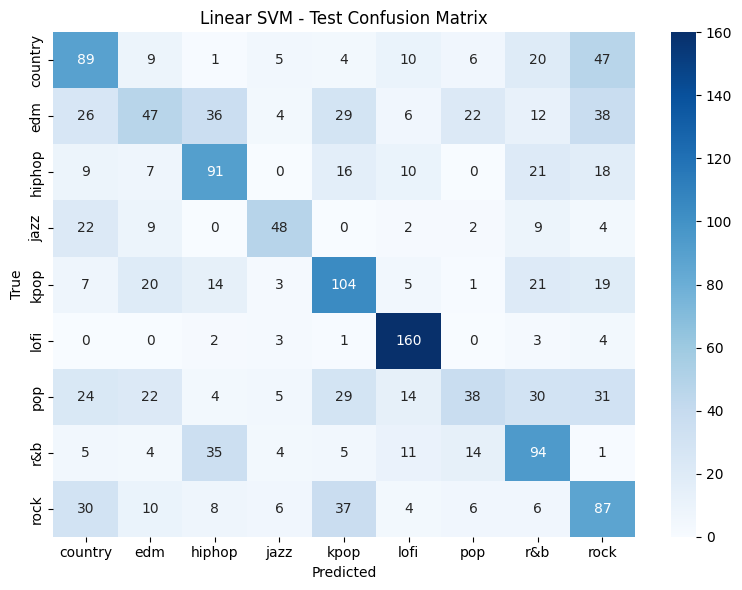

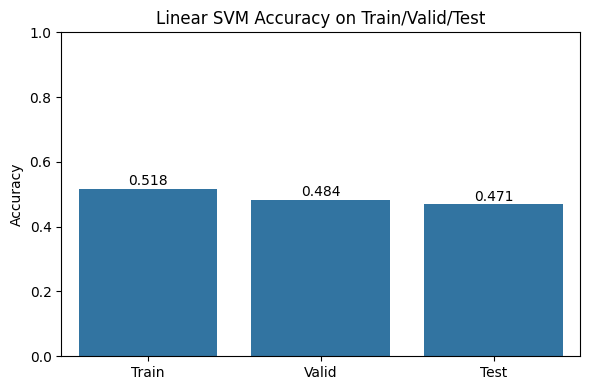

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix on test set
cm = confusion_matrix(y_test, test_preds)
labels = sorted(y_test.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Linear SVM - Test Confusion Matrix")
plt.tight_layout()
plt.show()

# Accuracy bar chart for train/valid/test
train_acc = accuracy_score(y_train, svm_pipeline.predict(X_train))

plt.figure(figsize=(6, 4))
sets = ["Train", "Valid", "Test"]
accs = [train_acc, val_acc, test_acc]

sns.barplot(x=sets, y=accs)
plt.ylim(0, 1)
for i, v in enumerate(accs):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")
plt.ylabel("Accuracy")
plt.title("Linear SVM Accuracy on Train/Valid/Test")
plt.tight_layout()
plt.show()